# Notebook 4 — Classification
**Variable cible : disease_risk** (0/1)


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../health_lifestyle_dataset.csv')
df['gender_enc'] = (df['gender'] == 'Male').astype(int)
df['hypertension'] = ((df['systolic_bp'] >= 140) | (df['diastolic_bp'] >= 90)).astype(int)
df['bmi_cat'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,100], labels=[0,1,2,3]).astype(int)
df['lifestyle_score'] = (
    df['daily_steps']/df['daily_steps'].max() + df['sleep_hours']/df['sleep_hours'].max() +
    df['water_intake_l']/df['water_intake_l'].max() - df['smoker'] - df['alcohol'] -
    df['bmi']/df['bmi'].max() - df['calories_consumed']/df['calories_consumed'].max())
features = ['age','bmi','daily_steps','sleep_hours','water_intake_l','calories_consumed',
            'smoker','alcohol','resting_hr','systolic_bp','diastolic_bp',
            'family_history','gender_enc','bmi_cat','hypertension','lifestyle_score']
X = df[features]; y = df['disease_risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train); X_te_sc = scaler.transform(X_test)
print(f'Train: {X_train.shape} | Ratio classe 1: {y_train.mean():.3f}')

Train: (80000, 16) | Ratio classe 1: 0.248


## 1. Modèle naïf (baseline absolu)

In [2]:
naive = np.zeros(len(y_test))
print(f'Modèle naïf | Accuracy: {accuracy_score(y_test,naive):.4f} | F1: {f1_score(y_test,naive,zero_division=0):.4f} | AUC: 0.5000')

Modèle naïf | Accuracy: 0.7518 | F1: 0.0000 | AUC: 0.5000


## 2. Entraînement et tuning des modèles

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(name, model, X_te, y_te):
    p = model.predict(X_te)
    try: auc = roc_auc_score(y_te, model.predict_proba(X_te)[:,1])
    except: auc = roc_auc_score(y_te, model.decision_function(X_te))
    print(f'{name:30s} | Acc={accuracy_score(y_te,p):.4f} | Prec={precision_score(y_te,p,zero_division=0):.4f} | Rec={recall_score(y_te,p,zero_division=0):.4f} | F1={f1_score(y_te,p,zero_division=0):.4f} | AUC={auc:.4f}')
    return model

# Logistic Regression
lr_s = RandomizedSearchCV(LogisticRegression(class_weight='balanced',max_iter=1000),
    {'C': np.logspace(-3,3,50),'penalty':['l1','l2'],'solver':['liblinear']},
    n_iter=20, cv=cv, scoring='f1', n_jobs=-1, random_state=42)
lr_s.fit(X_tr_sc, y_train)
best_lr = evaluate(f'LogReg (C={lr_s.best_params_["C"]:.4f})', lr_s.best_estimator_, X_te_sc, y_test)

# Random Forest
rf_s = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
    {'n_estimators':[100,200],'max_depth':[8,12,15],'max_samples':[0.5,0.7],'min_samples_leaf':[1,5,10]},
    n_iter=15, cv=cv, scoring='f1', n_jobs=-1, random_state=42)
rf_s.fit(X_train.values, y_train)
best_rf = evaluate('Random Forest (tuné)', rf_s.best_estimator_, X_test.values, y_test)

# XGBoost
xgb_s = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=3, n_jobs=-1, random_state=42, verbosity=0, eval_metric='logloss'),
    {'n_estimators':[100,200],'max_depth':[3,5,6],'learning_rate':[0.01,0.05,0.1],'subsample':[0.7,0.8,1.0]},
    n_iter=20, cv=cv, scoring='f1', n_jobs=-1, random_state=42)
xgb_s.fit(X_train.values, y_train)
best_xgb = evaluate('XGBoost (tuné)', xgb_s.best_estimator_, X_test.values, y_test)

## 3. SMOTE — Rééchantillonnage de la classe minoritaire

SMOTE crée synthétiquement des exemples de la classe minoritaire par interpolation entre voisins.  
On compare les mêmes modèles entraînés **avec SMOTE** vs **sans SMOTE** (class_weight='balanced').

In [ ]:
from imblearn.over_sampling import SMOTE

# Application de SMOTE sur le jeu d'entraînement
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
X_tr_sc_sm = scaler.fit_transform(X_train_sm)
print(f"Avant SMOTE : {y_train.value_counts().to_dict()}")
print(f"Après SMOTE : {pd.Series(y_train_sm).value_counts().to_dict()}")

print("\n--- Résultats AVEC SMOTE ---")

# Logistic Regression + SMOTE
lr_sm = LogisticRegression(C=lr_s.best_params_['C'], penalty=lr_s.best_params_['penalty'],
                           solver='liblinear', max_iter=1000)
lr_sm.fit(X_tr_sc_sm, y_train_sm)
evaluate('LogReg + SMOTE', lr_sm, X_te_sc, y_test)

# Random Forest + SMOTE (sans class_weight car SMOTE équilibre déjà)
rf_sm = RandomForestClassifier(**{k: v for k, v in rf_s.best_params_.items()},
                                n_jobs=-1, random_state=42)
rf_sm.fit(X_train_sm.values, y_train_sm)
evaluate('Random Forest + SMOTE', rf_sm, X_test.values, y_test)

# XGBoost + SMOTE (scale_pos_weight=1 car classes équilibrées)
xgb_sm = XGBClassifier(**{k: v for k, v in xgb_s.best_params_.items()},
                        scale_pos_weight=1, n_jobs=-1, random_state=42,
                        verbosity=0, eval_metric='logloss')
xgb_sm.fit(X_train_sm.values, y_train_sm)
evaluate('XGBoost + SMOTE', xgb_sm, X_test.values, y_test)

print("\n--- Comparaison synthétique ---")
print(f"{'Modèle':<35} {'Sans SMOTE':>12} {'Avec SMOTE':>12}")
print("-" * 60)
for name, m1, m2, X_te in [
    ('Logistic Regression', best_lr, lr_sm, X_te_sc),
    ('Random Forest',       best_rf, rf_sm, X_test.values),
    ('XGBoost',             best_xgb, xgb_sm, X_test.values)]:
    auc1 = roc_auc_score(y_test, m1.predict_proba(X_te)[:,1])
    auc2 = roc_auc_score(y_test, m2.predict_proba(X_te)[:,1])
    print(f"{name:<35} AUC={auc1:.4f}   AUC={auc2:.4f}")

## 3. Matrices de confusion

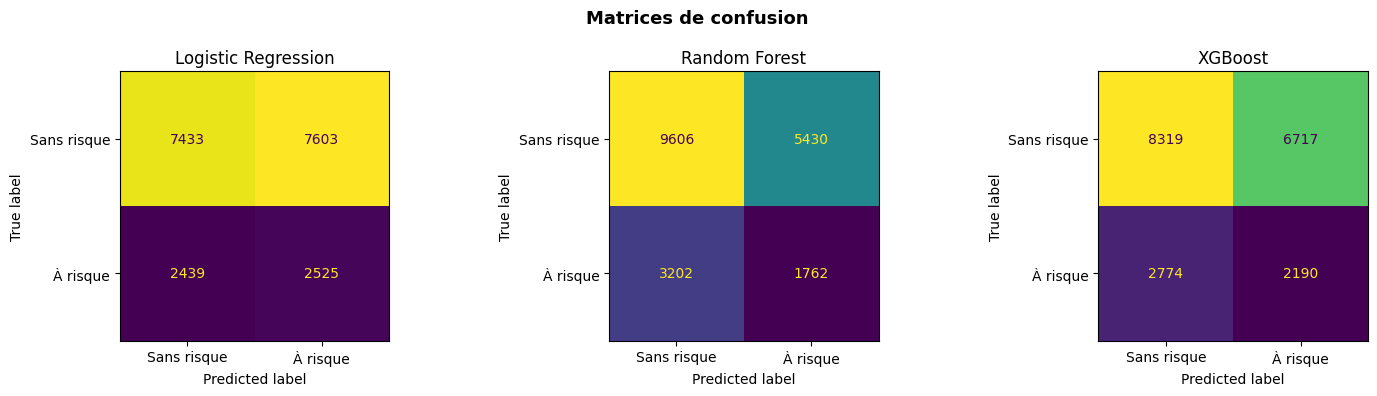

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model, X_te) in zip(axes, [
    ('Logistic Regression', best_lr, X_te_sc),
    ('Random Forest', best_rf, X_test.values),
    ('XGBoost', best_xgb, X_test.values)]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, model.predict(X_te)),
                           display_labels=['Sans risque','À risque']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle('Matrices de confusion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/confusion_matrices.png', dpi=150)
plt.show()

## 4. Courbe ROC

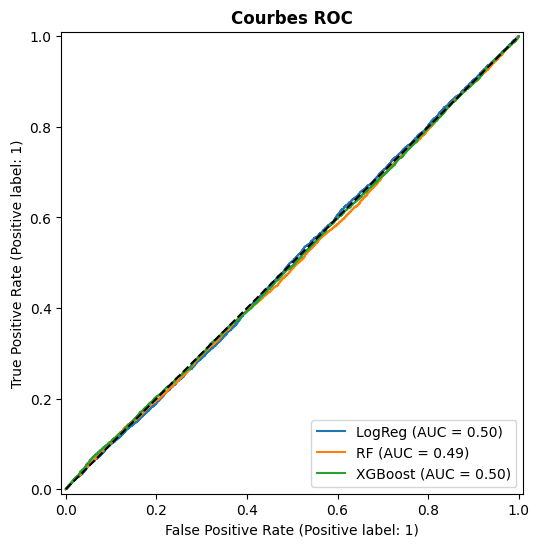

In [5]:
from sklearn.metrics import RocCurveDisplay
fig, ax = plt.subplots(figsize=(7,6))
for name, model, X_te in [('LogReg', best_lr, X_te_sc),('RF', best_rf, X_test.values),('XGBoost', best_xgb, X_test.values)]:
    RocCurveDisplay.from_estimator(model, X_te, y_test, ax=ax, name=name)
ax.plot([0,1],[0,1],'k--', label='Modèle naïf (AUC=0.5)')
ax.set_title('Courbes ROC', fontweight='bold')
plt.savefig('../figures/roc_curves.png', dpi=150)
plt.show()